In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits

import os.path as op
from specula.mmlib.utils import get_pupil_mask
from specula.mmlib.compute_rec import rec_ron_cov, rec_phot_cov
root_dir = '/raid1/mmenessini/calibration/RISTRETTOunobs'

In [10]:
import matplotlib as mpl
from cycler import cycler

cmap = mpl.colormaps['inferno'] # 1. Choose your colormap (e.g., 'hot', 'jet', 'turbo')
colors = cmap(np.linspace(0.1, 0.9, 7)) # 2. Extract a set of colors from it (e.g., 6 distinct colors across the map)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors) # 3. Apply it to the default line cycle
plt.rcParams['image.cmap'] = 'hot' # 4. Change the default colormap for images/scatter plots
plt.rcParams.update({
    "text.usetex": True, # Use LaTeX to write all text
    "font.family": "serif", # Use a serif font
    "font.serif": ["Computer Modern Roman"] # Specifically use the classic LaTeX font
})
plt.rcParams['image.origin'] = 'lower'

In [13]:
def get_ron_eq_shot(rMod,n_subap,seeing,RON,N,doplot:bool=False):
    pyr_mask = get_pupil_mask(npix=120,filepath=op.join(root_dir,'pupils',f'pyr_pupdata_{n_subap:.0f}x{n_subap:.0f}.fits'))
    frame = fits.getdata(op.join(root_dir,'frames',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_avg_frame.fits'))
    sn = fits.getdata(op.join(root_dir,'slopenulls',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_sn.fits'))+2e-2
    rec = fits.getdata(op.join(root_dir,'rec',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_{N}modes_rec.fits'))

    ron_cov = rec_ron_cov(rec,frame,mask=pyr_mask) 
    shot_cov = rec_phot_cov(rec,frame,mask=pyr_mask,sn=sn)
    nphot = ron_cov/shot_cov*RON

    if doplot:
        x = np.arange(N)+1
        plt.figure()
        plt.loglog(x,nphot)
        plt.loglog(x,np.sqrt(shot_cov/np.mean(nphot)))
        plt.loglog(x,np.sqrt(ron_cov*RON/np.mean(nphot)**2))
        plt.grid()

    return nphot,ron_cov,shot_cov

def get_ron_eq_shot_zwfs(dotDelay,n_subap,seeing,RON,N,doplot:bool=False):
    pyr_mask = get_pupil_mask(npix=120,filepath=op.join(root_dir,'pupils',f'pyr_pupdata_{n_subap:.0f}x{n_subap:.0f}.fits'))
    frame = fits.getdata(op.join(root_dir,'frames',f'z2wfs_{dotDelay:1.2f}delay_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_avg_frame.fits'))
    sn = fits.getdata(op.join(root_dir,'slopenulls',f'z2wfs_{dotDelay:1.2f}delay_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_sn.fits'))+2e-2
    im = fits.getdata(op.join(root_dir,'rec',f'z2wfs_{dotDelay:1.2f}delay_{n_subap:.0f}x{n_subap:.0f}_im.fits'))
    rec = np.linalg.pinv(im[:,:N])

    ron_cov = rec_ron_cov(rec,frame,mask=pyr_mask) 
    shot_cov = rec_phot_cov(rec,frame,mask=pyr_mask,sn=sn)
    nphot = ron_cov/shot_cov*RON

    if doplot:
        x = np.arange(N)+1
        plt.figure()
        plt.loglog(x,nphot)
        plt.loglog(x,np.sqrt(shot_cov/np.mean(nphot)))
        plt.loglog(x,np.sqrt(ron_cov*RON/np.mean(nphot)**2))
        plt.grid()

    return nphot,ron_cov,shot_cov

In [ ]:


# recs = []

# for delay in np.array([0.1,0.2,0.3,0.4,0.5]):
#     fname = f'z2wfs_{delay:1.2f}delay_48x48_im'
#     im = fits.getdata('/raid1/mmenessini/calibration/RISTRETTOunobs/im/'+fname+'.fits')
#     rec = np.linalg.pinv(im[:,:N])
#     recs.append(rec)

# recs = np.array(recs)

# prec = fits.getdata('/raid1/mmenessini/calibration/RISTRETTOunobs/rec/pyr0.0_48x48_1200modes_rec.fits')

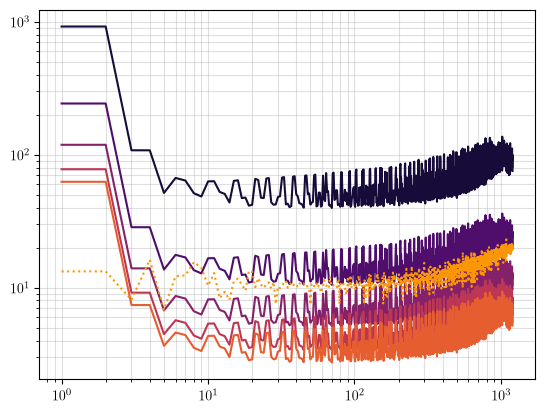

In [ ]:
N = 1200
x = np.arange(N)+1
seeing = 0.9
n_subap = 48
RON = 0.5
rMod = 0.0

dotDelays = np.array([0.2,0.25,0.3,0.35,0.4,0.5])

plt.figure()
_,pron,pshot = get_ron_eq_shot(rMod,n_subap,seeing,RON,N)
for i,delay in enumerate(dotDelays):
    _,zron,zshot = get_ron_eq_shot_zwfs(delay,n_subap,seeing,RON,N)
    plt.subplot(1,2,1)
    plt.loglog(x,zron,'--',label=f'{delay:1.2f}'+r'$\pi$')
    plt.subplot(1,2,2)
    plt.loglog(x,zshot,'--',label=f'{delay:1.2f}'+r'$\pi$')
plt.subplot(1,2,1)
plt.loglog(x,pron,':',c='k',label='unmod pyr')
plt.subplot(1,2,2)
plt.loglog(x,pshot,':',c='k',label='unmod pyr')
plt.subplot(1,2,1)
plt.legend(title='vZWFS delay')
plt.grid(which='both',alpha=0.4)
plt.xlabel('KL mode #')
plt.title('RON noise covariance')
plt.subplot(1,2,2)
plt.legend(title='vZWFS delay')
plt.grid(which='both',alpha=0.4)
plt.xlabel('KL mode #')
plt.title('Shot noise covariance')

In [ ]:
rMods = np.array([0.0,1.0,2.0,3.0])
seeings = np.array([0.5,0.7,0.9,1.1,1.3])

rMod_values = []
seeing_values = []
dfs = []

for rMod in rMods:
    for seeing in seeings:
        df = pd.read_csv(f'/raid1/mmenessini/results/RISTRETTOunobs/eb_csv/standard_INT_rMod{rMod:1.1f}_s{seeing:1.2f}_RON0.5_delay500.0us_VoverD1.46Hz_CL_1Nm.csv')
        dfs.append(df)
        rMod_values.append(rMod)
        seeing_values.append(seeing)

combined_df = pd.concat(
    [df.assign(rMod=param_r,seeing=param_s) for df, param_r, param_s in zip(dfs, rMod_values, seeing_values)],
    ignore_index=True,
)

for rMod in rMods:
    for seeing in seeings:
        df = pd.read_csv(f'/raid1/mmenessini/results/RISTRETTOunobs/eb_csv/multistage1200_INT_rMod{rMod:1.1f}_s{seeing:1.2f}_RON0.5_delay500.0us_VoverD1.46Hz_CL_1Nm.csv')
        dfs.append(df)
        rMod_values.append(rMod)
        seeing_values.append(seeing)

combined_df_ms = pd.concat(
    [df.assign(rMod=param_r,seeing=param_s) for df, param_r, param_s in zip(dfs, rMod_values, seeing_values)],
    ignore_index=True,
)


nsubaps_ms = combined_df_ms['Nsubaps']
modeids_ms = combined_df_ms['modeId']
rmods_ms = combined_df_ms['rMod']
ssval_ms = combined_df_ms['seeing']
photperms_ms = combined_df_ms['photPerMs']

nsubaps = combined_df['Nsubaps']
modeids = combined_df['modeId']
rmods = combined_df['rMod']
ssval = combined_df['seeing']
photperms = combined_df['photPerMs']

combined_df


,Nsubaps,freqInHz,photPerMs,modeId,gain,filter,residual,rMod,seeing
0,12,100.000000,1000.0,0,1.870953,INT,8.987103,0.0,0.5
1,16,100.000000,1000.0,0,1.899669,INT,4.845527,0.0,0.5
2,24,100.000000,1000.0,0,1.611360,INT,5.015181,0.0,0.5
3,48,100.000000,1000.0,0,1.228143,INT,6.651438,0.0,0.5
4,12,304.166667,1000.0,0,0.959637,INT,6.024103,0.0,0.5
...,...,...,...,...,...,...,...,...,...
1250055,24,4795.833333,100000.0,149,0.151660,INT,1.103429,3.0,1.3
1250056,48,4795.833333,100000.0,149,0.154077,INT,0.870105,3.0,1.3
1250057,16,5000.000000,100000.0,149,0.074316,INT,2.439486,3.0,1.3
1250058,24,5000.000000,100000.0,149,0.146661,INT,1.093688,3.0,1.3


/tmp/ipykernel_1314296/1883059494.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  freqs = combined_df[modeids == mode_idx][nsubaps == 48][rmods == rMod][ssval == seeing][photperms == 100000]['freqInHz']    #np.linspace(100,5000,25)
/tmp/ipykernel_1314296/1883059494.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  freqs = combined_df[modeids == mode_idx][nsubaps == 48][rmods == rMod][ssval == seeing][photperms == 100000]['freqInHz']    #np.linspace(100,5000,25)
/tmp/ipykernel_1314296/1883059494.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  freqs = combined_df[modeids == mode_idx][nsubaps == 48][rmods == rMod][ssval == seeing][photperms == 100000]['freqInHz']    #np.linspace(100,5000,25)
/tmp/ipykernel_1314296/1883059494.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  freqs = combined_df[modeids == mode_idx][nsubaps == 48][rmods == rMod][ssval =

Text(0.5, 1.0, 'KL mode 12 residual\n0.50" seeing')

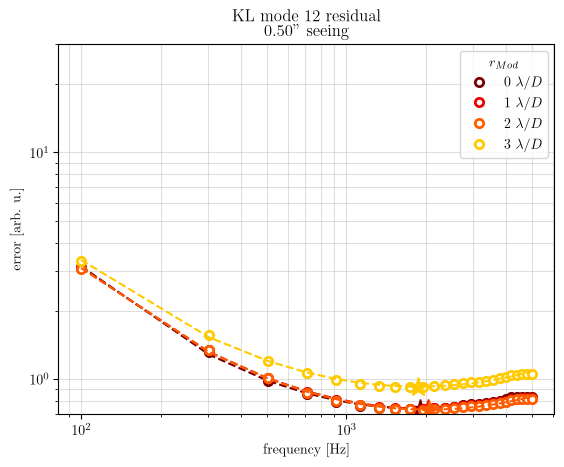

In [ ]:
mode_idx = 12
seeing = 0.5
freqs = combined_df[modeids == mode_idx][nsubaps == 48][rmods == rMod][ssval == seeing][photperms == 100000]['freqInHz']    #np.linspace(100,5000,25)

plt.figure()
for i,rMod in enumerate(rMods):
    y = combined_df[modeids == mode_idx][nsubaps == 48][rmods == rMod][ssval == seeing][photperms == 100000]['residual']
    p = np.polyfit(np.log(freqs),np.log(y),deg=3)
    plt.loglog(freqs,y,'o',c=f'C{i+1}',markersize=6,markerfacecolor='white', 
            markeredgewidth=2, label=f'{rMod:1.0f} '+r'$\lambda/D$')
    plt.loglog(freqs,np.exp(np.polyval(p,np.log(freqs))),'--',c=f'C{i+1}', label='')
    fmin = np.exp((np.sqrt(4*p[1]**2-12*p[0]*p[2])-2*p[1])/(6*p[0]))
    plt.loglog(fmin,np.exp(np.polyval(p,np.log(fmin))),'*',c=f'C{i+1}',markersize=15, label='')
plt.legend(title=r'$r_{Mod}$')
plt.grid(which='both',alpha=0.4)
plt.xlabel('frequency [Hz]')
plt.ylabel('error [arb. u.]')
plt.ylim([0.7,30])
plt.title(f'KL mode {mode_idx} residual\n{seeing:1.2f}" seeing')#{rMod} '+r'$\lambda/D$')

25 25
25 25
25 25
25 25


/tmp/ipykernel_1314296/170623821.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y = combined_df[modeids == mode_idx][nsubaps == n_subap][rmods == rMod][ssval == seeing][photperms == 10000]['residual']
/tmp/ipykernel_1314296/170623821.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y = combined_df[modeids == mode_idx][nsubaps == n_subap][rmods == rMod][ssval == seeing][photperms == 10000]['residual']
/tmp/ipykernel_1314296/170623821.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y = combined_df[modeids == mode_idx][nsubaps == n_subap][rmods == rMod][ssval == seeing][photperms == 10000]['residual']
/tmp/ipykernel_1314296/170623821.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y = combined_df[modeids == mode_idx][nsubaps == n_subap][rmods == rMod][ssval == seeing][photperms == 10000]['residual']
/tmp/ipykernel_1314296/170623821.py:11: RuntimeW

Text(0.5, 1.0, 'KL mode 12 residual\n1.30" seeing')

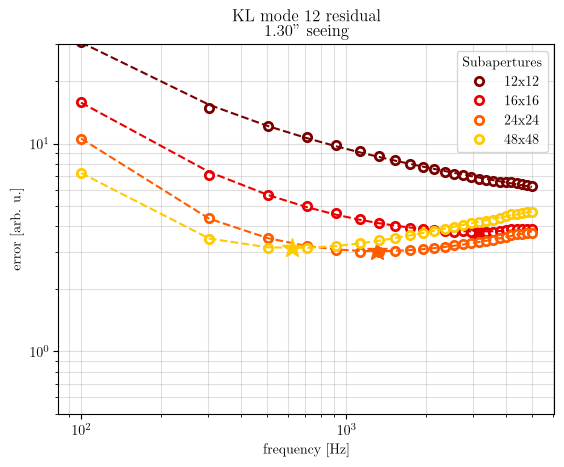

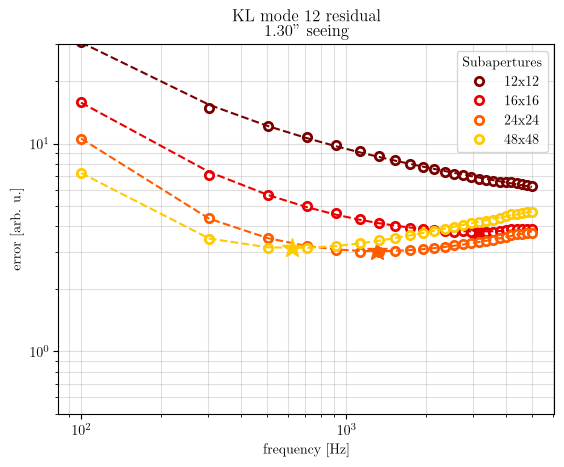

In [ ]:
rMod = 1
n_subaps = np.array([12,16,24,48])

plt.figure()
for i,n_subap in enumerate(n_subaps):
    y = combined_df[modeids == mode_idx][nsubaps == n_subap][rmods == rMod][ssval == seeing][photperms == 10000]['residual']
    p = np.polyfit(np.log(freqs),np.log(y),deg=3)
    plt.loglog(freqs,y,'o',c=f'C{i+1}',markersize=6,markerfacecolor='white', 
            markeredgewidth=2, label=f'{n_subap}x{n_subap}')
    plt.loglog(freqs,np.exp(np.polyval(p,np.log(freqs))),'--',c=f'C{i+1}', label='')
    fmin = np.exp((np.sqrt(4*p[1]**2-12*p[0]*p[2])-2*p[1])/(6*p[0]))
    plt.loglog(fmin,np.exp(np.polyval(p,np.log(fmin))),'*',c=f'C{i+1}',markersize=15, label='')
plt.legend(title=r'Subapertures')
plt.grid(which='both',alpha=0.4)
plt.xlabel('frequency [Hz]')
plt.ylabel('error [arb. u.]')
plt.ylim([0.5,30])
plt.title(f'KL mode {mode_idx} residual\n{seeing:1.2f}" seeing')#{rMod} '+r'$\lambda/D$')


freqs_ms = combined_df[modeids_ms == mode_idx][nsubaps_ms == 48][rmods_ms == rMod][ssval_ms == seeing][photperms_ms == 100000]['freqInHz']    #np.linspace(100,5000,25)


plt.figure()
for i,n_subap in enumerate(n_subaps):
    y = combined_df_ms[modeids_ms == mode_idx][nsubaps_ms == n_subap][rmods_ms == rMod][ssval_ms == seeing][photperms_ms == 10000]['residual']
    y = y[len(y)//2:]
    print(len(y),len(freqs_ms))
    p = np.polyfit(np.log(freqs_ms),np.log(y),deg=3)
    plt.loglog(freqs_ms,y,'o',c=f'C{i+1}',markersize=6,markerfacecolor='white', 
            markeredgewidth=2, label=f'{n_subap}x{n_subap}')
    plt.loglog(freqs_ms,np.exp(np.polyval(p,np.log(freqs_ms))),'--',c=f'C{i+1}', label='')
    fmin = np.exp((np.sqrt(4*p[1]**2-12*p[0]*p[2])-2*p[1])/(6*p[0]))
    plt.loglog(fmin,np.exp(np.polyval(p,np.log(fmin))),'*',c=f'C{i+1}',markersize=15, label='')
plt.legend(title=r'Subapertures')
plt.grid(which='both',alpha=0.4)
plt.xlabel('frequency [Hz]')
plt.ylabel('error [arb. u.]')
plt.ylim([0.5,30])
plt.title(f'KL mode {mode_idx} residual\n{seeing:1.2f}" seeing')#{rMod} '+r'$\lambda/D$')

In [ ]:
fluxes = np.logspace(6,8,5)/1e+3
n_subaps = np.array([12,16,24,48])
flux = 1e+3
seeing = 1.1
rMod = 1

res_opt = np.ones([len(n_subaps),150])*np.nan
freq_opt = np.ones([len(n_subaps),150])*np.nan

for j,mode_idx in enumerate(range(20,150)):
    for i,n_subap in enumerate(n_subaps):
        y = combined_df[modeids == mode_idx][nsubaps == n_subap][rmods == rMod][ssval == seeing][photperms == flux]['residual']
        if len(y) == len(freqs):
            p = np.polyfit(np.log(freqs),np.log(y),deg=3)
            fmin = np.exp((np.sqrt(4*p[1]**2-12*p[0]*p[2])-2*p[1])/(6*p[0]))
            res_opt[i,j] = np.exp(np.polyval(p,np.log(fmin)))
            freq_opt[i,j] = fmin

/tmp/ipykernel_1313532/506434409.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y = combined_df[modeids == mode_idx][nsubaps == n_subap][rmods == rMod][ssval == seeing][photperms == flux]['residual']
/tmp/ipykernel_1313532/506434409.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y = combined_df[modeids == mode_idx][nsubaps == n_subap][rmods == rMod][ssval == seeing][photperms == flux]['residual']
/tmp/ipykernel_1313532/506434409.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y = combined_df[modeids == mode_idx][nsubaps == n_subap][rmods == rMod][ssval == seeing][photperms == flux]['residual']
/tmp/ipykernel_1313532/506434409.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y = combined_df[modeids == mode_idx][nsubaps == n_subap][rmods == rMod][ssval == seeing][photperms == flux]['residual']
/tmp/ipykernel_1313532/506434409.py:12: UserWarn

IndexError: index 4 is out of bounds for axis 0 with size 4

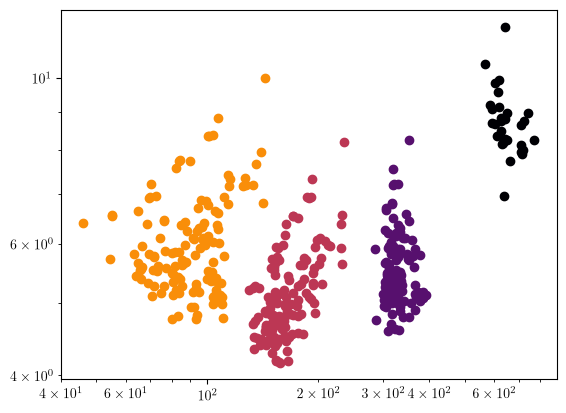

In [ ]:
cmap = mpl.colormaps['inferno'] # 1. Choose your colormap (e.g., 'hot', 'jet', 'turbo')
colors = cmap(np.linspace(0.0, 1.0, 5)) # 2. Extract a set of colors from it (e.g., 6 distinct colors across the map)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors) # 3. Apply it to the default line cycle

mmin = 0

plt.figure()
for i,flux in enumerate(nsubaps):
    for mode in range(mmin,150):
        plt.loglog(freq_opt[i,mode],res_opt[i,mode],'o',c=f'C{i}',label=f'{flux*1e-3:1.1e} phot/ms')
# plt.legend(title='Fluxes')
plt.grid(which='both',alpha=0.4)
plt.xlabel('frequency [Hz]')
plt.ylabel('error [arb. u.]')
plt.ylim([0.5,10])
plt.title(f'{seeing:1.2f}" seeing, {rMod} '+r'$\lambda/D$')

Text(0.5, 1.0, '0.90" seeing, 3.0 $\\lambda/D$')

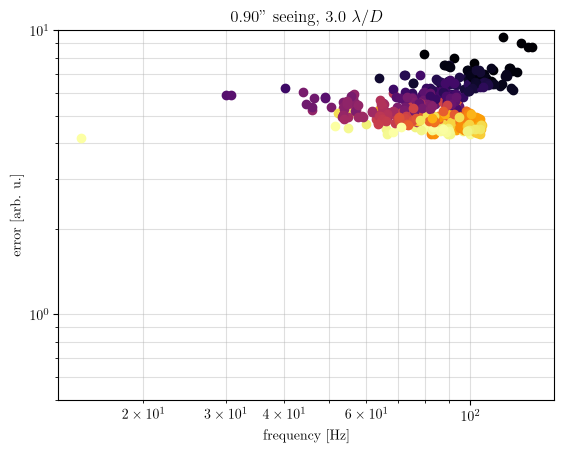

In [ ]:
cmap = mpl.colormaps['inferno'] # 1. Choose your colormap (e.g., 'hot', 'jet', 'turbo')
colors = cmap(np.linspace(0.0, 1.0, 130)) # 2. Extract a set of colors from it (e.g., 6 distinct colors across the map)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors) # 3. Apply it to the default line cycle

plt.figure()
for i,flux in enumerate(fluxes):
    for j,mode in enumerate(range(mmin,150)):
        plt.loglog(freq_opt[i,mode],res_opt[i,mode],'o',c=f'C{j}',label=f'{flux*1e-3:1.1e} phot/ms')
# plt.legend(title='Fluxes')
plt.grid(which='both',alpha=0.4)
plt.xlabel('frequency [Hz]')
plt.ylabel('error [arb. u.]')
plt.ylim([0.5,10])
plt.title(f'{seeing:1.2f}" seeing, {rMod} '+r'$\lambda/D$')
